# CSC3042F Assignment 2: Sequence Modelling

## Encoder-Decoder Models for Grapheme-to-Phoneme Conversion

- Name: Timera Govender

_______


#### Imports & Reproducibility

In [1]:
# Standard Library Imports
import os
import random
from collections import Counter
from typing import List, Tuple, Dict

# Data Processing Imports
import numpy as np
import pandas as pd

# Plotting Imports
import matplotlib.pyplot as plt

# PyTorch Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Evaluation Imports
try:
    import editdistance
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "editdistance"])
    import editdistance

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# File Paths
DATA_DIR = "data"

TRAIN_PATH = os.path.join(DATA_DIR, "g2p_train.csv")
VAL_PATH = os.path.join(DATA_DIR, "g2p_val.csv")
if not os.path.exists(VAL_PATH):
    VAL_PATH = os.path.join(DATA_DIR, "g2p_valid.csv")
TEST_PATH = os.path.join(DATA_DIR, "g2p_test.csv")

os.makedirs("results", exist_ok=True)

Using device: cpu


____________

### 1. Data Preprocessing [3 marks]

#### Load Datasets

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

# Display DataFrame shapes
print("Training Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Testing Shape:", test_df.shape)
print("")

# Split each dataframe into lists of words and target phoneme sequences
train_words = train_df["word"].astype(str).tolist()
train_phonemes = train_df["phonemes"].astype(str).tolist()

val_words = val_df["word"].astype(str).tolist()
val_phonemes = val_df["phonemes"].astype(str).tolist()

test_words = test_df["word"].astype(str).tolist()
test_phonemes = test_df["phonemes"].astype(str).tolist()

# Display Lengths of the Lists
print("Training Words:", len(train_words))
print("Training Phonemes:", len(train_phonemes))
print("")
print("Validation Words:", len(val_words))
print("Validation Phonemes:", len(val_phonemes))
print("")
print("Testing Words:", len(test_words))
print("Testing Phonemes:", len(test_phonemes))

Training Shape: (92426, 2)
Validation Shape: (11553, 2)
Testing Shape: (11554, 2)

Training Words: 92426
Training Phonemes: 92426

Validation Words: 11553
Validation Phonemes: 11553

Testing Words: 11554
Testing Phonemes: 11554


#### Vocabulary Construction

In [3]:
# Character Vocabulary Creation
def build_char_vocab(words):
    counter = Counter()
    for word in words:
        counter.update(list(word.lower()))

    char_to_idx = {
        "<PAD>": 0, 
        "<SOS>": 1, 
        "<EOS>": 2, 
        "<UNK>": 3
        }
    
    for char, _ in counter.most_common():
        char_to_idx[char] = len(char_to_idx)

    return char_to_idx

# Phoneme Vocabulary Creation
def build_phoneme_vocab(phoneme_seqs):
    counter = Counter()
    for seq in phoneme_seqs:
        counter.update(seq.split())

    phoneme_to_idx = {
        "<PAD>": 0, 
        "<SOS>": 1, 
        "<EOS>": 2, 
        "<UNK>": 3
        }
    
    for phoneme, _ in counter.most_common():
        phoneme_to_idx[phoneme] = len(phoneme_to_idx)

    return phoneme_to_idx

# Build Vocabularies
char_to_idx = build_char_vocab(train_words) 
phoneme_to_idx = build_phoneme_vocab(train_phonemes)
idx_to_phoneme = {idx: phoneme for phoneme, idx in phoneme_to_idx.items()}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}


# Display Vocabulary Sizes
print("Character Vocabulary Size:", len(char_to_idx))
print("Phoneme Vocabulary Size:", len(phoneme_to_idx))
print("")


Character Vocabulary Size: 30
Phoneme Vocabulary Size: 73



#### Dataset and DataLoaders

In [4]:
class G2PDataset(Dataset):
    def __init__(self, words, phoneme_seqs, char_to_idx, phoneme_to_idx):
        self.words = words
        self.phoneme_seqs = phoneme_seqs
        self.char_to_idx = char_to_idx
        self.phoneme_to_idx = phoneme_to_idx

        self.char_unk_idx = char_to_idx["<UNK>"]
        self.phoneme_unk_idx = phoneme_to_idx["<UNK>"]
        self.sos_idx = phoneme_to_idx["<SOS>"]
        self.eos_idx = phoneme_to_idx["<EOS>"]

    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, idx):
        word  = self.words[idx].lower()
        phoneme_seqs = self.phoneme_seqs[idx]

        # Encode source word as character IDs
        src_ids = [
            self.char_to_idx.get(char, self.char_unk_idx) 
            for char in word
        ]

        # Encode target phoneme sequence as phoneme IDs
        phoneme_tokens = phoneme_seqs.split()

        target_ids = [self.sos_idx] + [
            self.phoneme_to_idx.get(phoneme, self.phoneme_unk_idx) 
            for phoneme in phoneme_tokens
        ]

        target_ids.append(self.eos_idx)

        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(target_ids, dtype=torch.long)

# Create Datasets
train_dataset = G2PDataset(train_words, train_phonemes, char_to_idx, phoneme_to_idx)
val_dataset = G2PDataset(val_words, val_phonemes, char_to_idx, phoneme_to_idx)
test_dataset = G2PDataset(test_words, test_phonemes, char_to_idx, phoneme_to_idx)

# Sanity check on one example
print("Sanity Check on First Training Example in Dataset:")
src_ids, target_ids = train_dataset[0]

src_chars = [idx_to_char[idx.item()] for idx in src_ids]
target_phonemes = [idx_to_phoneme[idx.item()] for idx in target_ids]

print("Decoded source:", src_chars)
print("Decoded target:", target_phonemes)
print("")

print("Source IDs:", src_ids)
print("Target IDs:", target_ids)
print("Source length:", len(src_ids))
print("Target length:", len(target_ids))  

# Collate function for DataLoader  
def g2p_collate_fn(batch):
    src_batch, target_batch = zip(*batch)

    src_padded = nn.utils.rnn.pad_sequence(
        src_batch, 
        batch_first=True, 
        padding_value=char_to_idx["<PAD>"]
        )
    
    target_padded = nn.utils.rnn.pad_sequence(
        target_batch,
        batch_first=True,
        padding_value=phoneme_to_idx["<PAD>"]
        )
    
    return src_padded, target_padded

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=g2p_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=g2p_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=g2p_collate_fn
)

# Sanity check on one batch
print("Sanity Check on One Batch from Training DataLoader:")
src_batch, target_batch = next(iter(train_loader))

print("Source batch shape:", src_batch.shape)
print("Target batch shape:", target_batch.shape)

src_example = src_batch[0]
target_example = target_batch[0]

src_example_chars = [idx_to_char[idx.item()] for idx in src_example]
target_example_phonemes = [idx_to_phoneme[idx.item()] for idx in target_example]

print("")
print("Decoded source example:", src_example_chars)
print("Source example IDs:", src_example)
print("")
print("Decoded target example:", target_example_phonemes)
print("Target example IDs:", target_example)

Sanity Check on First Training Example in Dataset:
Decoded source: ['v', 'i', 'g', 'i', 'l']
Decoded target: ['<SOS>', 'V', 'IH1', 'JH', 'AH0', 'L', '<EOS>']

Source IDs: tensor([25,  7, 18,  7, 11])
Target IDs: tensor([ 1, 25, 22, 38,  4,  6,  2])
Source length: 5
Target length: 7
Sanity Check on One Batch from Training DataLoader:
Source batch shape: torch.Size([64, 14])
Target batch shape: torch.Size([64, 14])

Decoded source example: ['l', 'u', 't', 'f', 'a', 'l', 'l', 'a', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Source example IDs: tensor([11, 16, 12, 23,  5, 11, 11,  5,  0,  0,  0,  0,  0,  0])

Decoded target example: ['<SOS>', 'L', 'AH0', 'T', 'F', 'AE1', 'L', 'AH0', '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']
Target example IDs: tensor([ 1,  6,  4,  8, 24, 21,  6,  4,  2,  0,  0,  0,  0,  0])


#### Exploratory Data Analysis

The following histograms show the distribution of source word lengths and target phoneme sequence lengths across the splits. These distributions are useful because they indicate the typical sequence lengths the encoder and decoder must process.

Vocabulary Sizes:
Source vocabulary size: 30
Target vocabulary size: 73

Dataset Sizes:
Training set size: 92426
Validation set size: 11553
Test set size: 11554

Training Word Lengths:
Min: 1
Max: 33
Mean: 7.4

Training Phoneme Lengths:
Min: 1
Max: 32
Mean: 6.31

Validation Word Lengths:
Min: 1
Max: 18
Mean: 7.39

Validation Phoneme Lengths:
Min: 1
Max: 18
Mean: 6.3

Test Word Lengths:
Min: 1
Max: 18
Mean: 7.38

Test Phoneme Lengths:
Min: 1
Max: 18
Mean: 6.31



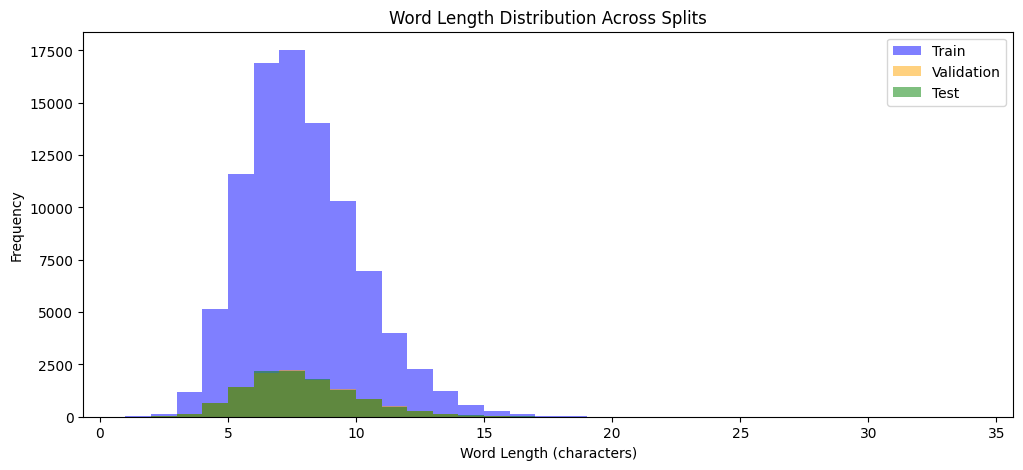

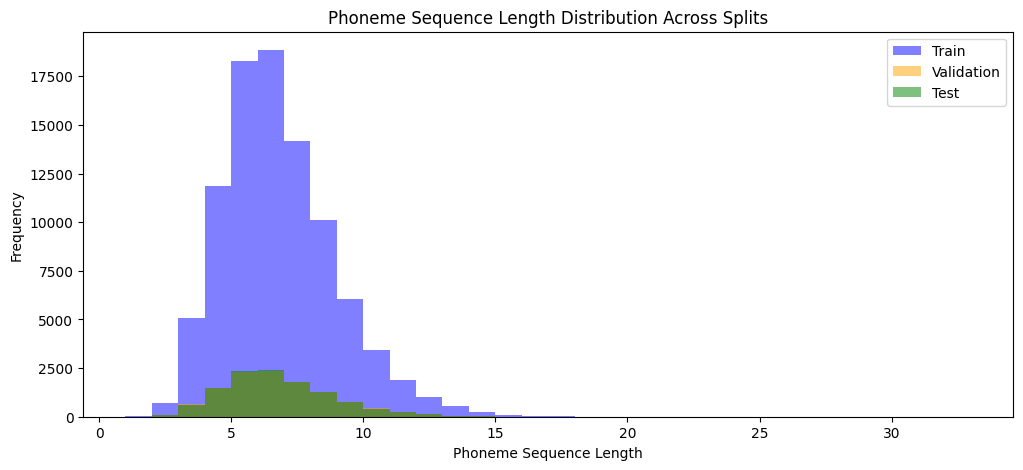

In [5]:
# Vocabulary Sizes
print("Vocabulary Sizes:")
print("Source vocabulary size:", len(char_to_idx))
print("Target vocabulary size:", len(phoneme_to_idx))
print("")

# Dataset Sizes
print("Dataset Sizes:")
print("Training set size:", len(train_dataset))
print("Validation set size:", len(val_dataset))
print("Test set size:", len(test_dataset))
print("")

# Summaries & Histograms of word length and phoneme sequence length

train_word_lengths = [len(word) for word in train_words]
train_phoneme_lengths = [len(seq.split()) for seq in train_phonemes]

val_word_lengths = [len(word) for word in val_words]
val_phoneme_lengths = [len(seq.split()) for seq in val_phonemes]

test_word_lengths = [len(word) for word in test_words]
test_phoneme_lengths = [len(seq.split()) for seq in test_phonemes]

#Summaries:
print("Training Word Lengths:")
print("Min:", min(train_word_lengths))
print("Max:", max(train_word_lengths))
print("Mean:", round(np.mean(train_word_lengths), 2))
print("")

print("Training Phoneme Lengths:")
print("Min:", min(train_phoneme_lengths))
print("Max:", max(train_phoneme_lengths))
print("Mean:", round(np.mean(train_phoneme_lengths), 2))
print("")

print("Validation Word Lengths:")
print("Min:", min(val_word_lengths))
print("Max:", max(val_word_lengths))
print("Mean:", round(np.mean(val_word_lengths), 2))
print("")

print("Validation Phoneme Lengths:")
print("Min:", min(val_phoneme_lengths))
print("Max:", max(val_phoneme_lengths))
print("Mean:", round(np.mean(val_phoneme_lengths), 2))
print("")

print("Test Word Lengths:")
print("Min:", min(test_word_lengths))
print("Max:", max(test_word_lengths))
print("Mean:", round(np.mean(test_word_lengths), 2))
print("")

print("Test Phoneme Lengths:")
print("Min:", min(test_phoneme_lengths))
print("Max:", max(test_phoneme_lengths))
print("Mean:", round(np.mean(test_phoneme_lengths), 2))
print("")

# Histograms

# Word Lengths
plt.figure(figsize=(12, 5))
plt.hist(train_word_lengths, bins=range(1, max(train_word_lengths) + 2), alpha=0.5, label="Train", color="blue")
plt.hist(val_word_lengths, bins=range(1, max(val_word_lengths) + 2), alpha=0.5, label="Validation", color="orange")
plt.hist(test_word_lengths, bins=range(1, max(test_word_lengths) + 2), alpha=0.5, label="Test", color="green")
plt.title("Word Length Distribution Across Splits")
plt.xlabel("Word Length (characters)")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("results/word_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Phoneme Lengths
plt.figure(figsize=(12, 5))
plt.hist(train_phoneme_lengths, bins=range(1, max(train_phoneme_lengths) + 2), alpha=0.5, label="Train", color="blue")
plt.hist(val_phoneme_lengths, bins=range(1, max(val_phoneme_lengths) + 2), alpha=0.5, label="Validation", color="orange")
plt.hist(test_phoneme_lengths, bins=range(1, max(test_phoneme_lengths) + 2), alpha=0.5, label="Test", color="green")
plt.title("Phoneme Sequence Length Distribution Across Splits")
plt.xlabel("Phoneme Sequence Length")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("results/phoneme_length_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

______________

### 2. LSTM Cell

In [6]:
# LSTMCell Implementation
class LSTMCell(nn.Module):
    """
    Single LSTM cell implemented from scratch using the six LSTM equations.

    Parameters:
        input_size: dimensionality of input x_t
        hidden_size: dimensionality of hidden state h_t and cell state c_t
    """

    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # Forget gate: f_t = sigmoid(W_f x_t + U_f h_{t-1} + b_f)
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))

        # Input gate: i_t = sigmoid(W_i x_t + U_i h_{t-1} + b_i)
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))

        # Output gate: o_t = sigmoid(W_o x_t + U_o h_{t-1} + b_o)
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        # Candidate cell state: c_tilde = tanh(W_c x_t + U_c h_{t-1} + b_c)
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h, c):
        """
        Performs one LSTM timestep.

        Parameters:
            x: input at current timestep, shape (batch_size, input_size)
            h: previous hidden state, shape (batch_size, hidden_size)
            c: previous cell state, shape (batch_size, hidden_size)

        Returns:
            h_new: new hidden state, shape (batch_size, hidden_size)
            c_new: new cell state, shape (batch_size, hidden_size)
        """

        f = torch.sigmoid(self.W_f(x) + self.U_f(h) + self.b_f)
        i = torch.sigmoid(self.W_i(x) + self.U_i(h) + self.b_i)
        o = torch.sigmoid(self.W_o(x) + self.U_o(h) + self.b_o)

        c_tilde = torch.tanh(self.W_c(x) + self.U_c(h) + self.b_c)

        c_new = f * c + i * c_tilde
        h_new = o * torch.tanh(c_new)

        return h_new, c_new

# LSTMCell Shape Test
torch.manual_seed(SEED)

batch_size = 4
input_size = 8
hidden_size = 16

cell = LSTMCell(input_size=input_size, hidden_size=hidden_size)

x = torch.randn(batch_size, input_size)
h_prev = torch.zeros(batch_size, hidden_size)
c_prev = torch.zeros(batch_size, hidden_size)

h_new, c_new = cell(x, h_prev, c_prev)

print("Input x shape:", x.shape)
print("Previous hidden shape:", h_prev.shape)
print("Previous cell shape:", c_prev.shape)
print("")
print("New hidden shape:", h_new.shape)
print("New cell shape:", c_new.shape)

Input x shape: torch.Size([4, 8])
Previous hidden shape: torch.Size([4, 16])
Previous cell shape: torch.Size([4, 16])

New hidden shape: torch.Size([4, 16])
New cell shape: torch.Size([4, 16])


In [7]:
class ContextLSTMCell(nn.Module):
    """
    LSTM cell with an additional context vector z entering each gate.

    This implements the decoder equations for:
    - Setup 2: fixed context vector
    - Setup 3: attention-based dynamic context vector

    Parameters:
        input_size: dimensionality of decoder input embedding y_{t-1}
        hidden_size: dimensionality of hidden state, cell state, and context vector
    """

    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # Forget gate
        self.W_f = nn.Linear(input_size, hidden_size, bias=False)
        self.U_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_f = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_f = nn.Parameter(torch.zeros(hidden_size))

        # Input gate
        self.W_i = nn.Linear(input_size, hidden_size, bias=False)
        self.U_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_i = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_i = nn.Parameter(torch.zeros(hidden_size))

        # Output gate
        self.W_o = nn.Linear(input_size, hidden_size, bias=False)
        self.U_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_o = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_o = nn.Parameter(torch.zeros(hidden_size))

        # Candidate cell content
        self.W_c = nn.Linear(input_size, hidden_size, bias=False)
        self.U_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.V_c = nn.Linear(hidden_size, hidden_size, bias=False)
        self.b_c = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h, c, z):
        """
        Performs one context-aware LSTM timestep.

        Parameters:
            x: current decoder input embedding, shape (batch, input_size)
            h: previous hidden state, shape (batch, hidden_size)
            c: previous cell state, shape (batch, hidden_size)
            z: context vector, shape (batch, hidden_size)

        Returns:
            h_new: new hidden state, shape (batch, hidden_size)
            c_new: new cell state, shape (batch, hidden_size)
        """

        # Forget gate:
        # f = sigmoid(W_f x + U_f h + V_f z + b_f)
        f = torch.sigmoid(
            self.W_f(x) + self.U_f(h) + self.V_f(z) + self.b_f
        )

        # Input gate:
        # i = sigmoid(W_i x + U_i h + V_i z + b_i)
        i = torch.sigmoid(
            self.W_i(x) + self.U_i(h) + self.V_i(z) + self.b_i
        )

        # Output gate:
        # o = sigmoid(W_o x + U_o h + V_o z + b_o)
        o = torch.sigmoid(
            self.W_o(x) + self.U_o(h) + self.V_o(z) + self.b_o
        )

        # Candidate cell:
        c_tilde = torch.tanh(
            self.W_c(x) + self.U_c(h) + self.V_c(z) + self.b_c
        )

        # New cell state:
        c_new = f * c + i * c_tilde

        # New hidden state:
        h_new = o * torch.tanh(c_new)

        return h_new, c_new
    
# Sanity check on ContextLSTMCell shapes

torch.manual_seed(SEED)

batch_size = 4
input_size = 8
hidden_size = 16

context_cell = ContextLSTMCell(input_size=input_size, hidden_size=hidden_size)

x = torch.randn(batch_size, input_size)
h_prev = torch.zeros(batch_size, hidden_size)
c_prev = torch.zeros(batch_size, hidden_size)
z = torch.randn(batch_size, hidden_size)

h_new, c_new = context_cell(x, h_prev, c_prev, z)

print("Input x shape:", x.shape)
print("Previous hidden shape:", h_prev.shape)
print("Previous cell shape:", c_prev.shape)
print("")
print("Context z shape:", z.shape)
print("")
print("New hidden shape:", h_new.shape)
print("New cell shape:", c_new.shape)

Input x shape: torch.Size([4, 8])
Previous hidden shape: torch.Size([4, 16])
Previous cell shape: torch.Size([4, 16])

Context z shape: torch.Size([4, 16])

New hidden shape: torch.Size([4, 16])
New cell shape: torch.Size([4, 16])


_________________

### 3. Encoder-Decoder implementation [9 marks]

#### Encoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()

        self.src_vocab_size = src_vocab_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers


        self.embedding = nn.Embedding(
            num_embeddings=src_vocab_size, 
            embedding_dim=embed_dim,
            padding_idx=char_to_idx["<PAD>"]
            )
        
        self.cells = nn.ModuleList([
            LSTMCell(
                input_size=embed_dim if layer == 0 else hidden_size, 
                hidden_size=hidden_size
            )
            for layer in  range(num_layers)
        ])

    def forward(self, src):
        # src: (batch, src_len)
        # Returns: (all_h, (h_n, c_n)) 
        # all_h: (src_len, batch, hidden_size)
        # h_n, c_n: (num_layers, batch, hidden_size)
        
        batch_size, src_len = src.size()

        embedded = self.embedding(src)  # (batch, src_len, embed_dim)
        embedded = embedded.transpose(0, 1)  # (src_len, batch, embed_dim)

        h = [
            torch.zeros(batch_size, self.hidden_size, device=src.device) 
            for _ in range(self.num_layers)
            ]
        
        c = [
            torch.zeros(batch_size, self.hidden_size, device=src.device) 
            for _ in range(self.num_layers)
            ]

        all_h = []

        for t in range(src_len):
            x_t = embedded[t] # (batch, embed_dim) for first layer, then (batch, hidden_size) for subsequent layers

            for layer, cell in enumerate(self.cells):
                h[layer], c[layer] = cell(x_t, h[layer], c[layer])
                x_t = h[layer]  # Input to next layer is hidden state of current layer
            
            all_h.append(h[-1])  # Append the hidden state of the last layer

        all_h = torch.stack(all_h, dim=0)  # (src_len, batch, hidden_size)
        h_n = torch.stack(h, dim=0)  # (num_layers, batch, hidden_size)
        c_n = torch.stack(c, dim=0)  # (num_layers, batch, hidden_size)

        return all_h, (h_n, c_n)
    
# Sanity check on Encoder shapes

torch.manual_seed(SEED)

src_batch, target_batch = next(iter(train_loader))

encoder = Encoder(
    src_vocab_size=len(char_to_idx), 
    embed_dim=32, 
    hidden_size=64, 
    num_layers=1
)

all_h, (h_n, c_n) = encoder(src_batch)

print("Source batch shape:", src_batch.shape)
print("All hidden states shape:", all_h.shape)
print("")
print("Final hidden state shape:", h_n.shape)
print("Final cell state shape:", c_n.shape) 

Source batch shape: torch.Size([64, 14])
All hidden states shape: torch.Size([14, 64, 64])

Final hidden state shape: torch.Size([1, 64, 64])
Final cell state shape: torch.Size([1, 64, 64])


#### Decoder

In [9]:
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = "none"):
        assert context_mode in {"none", "fixed", "attn"}

        super().__init__()

        self.tgt_vocab_size = tgt_vocab_size
        self.embed_dim = embed_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.context_mode = context_mode

        self.embedding = nn.Embedding(
            num_embeddings=tgt_vocab_size,
            embedding_dim=embed_dim,
            padding_idx=phoneme_to_idx["<PAD>"]
        )

        cell_class = LSTMCell if context_mode == "none" else ContextLSTMCell

        self.cells = nn.ModuleList([
            cell_class(
                input_size=embed_dim if layer == 0 else hidden_size, 
                hidden_size=hidden_size
            )
            for layer in range(num_layers)
        ])

        self.output_layer = nn.Linear(hidden_size, tgt_vocab_size)
    
    def forward(self, tgt, hidden, encoder_outputs=None):
        # tgt: (batch, tgt_len)
        # hidden: (h_0, c_0)
        #   h_0, c_0: (num_layers, batch, hidden_size)
        # encoder_outputs: optional (only needed for attention)
        #   (src_len, batch, hidden_size)
        #
        # Returns: (logits, (h_n, c_n))
        # logits: (batch, tgt_len, tgt_vocab_size)
        # h_n, c_n: (num_layers, batch, hidden_size)
        
        batch_size, tgt_len = tgt.size()

        embedded = self.embedding(tgt)  # (batch, tgt_len, embed_dim)
        embedded = embedded.transpose(0, 1)  # (tgt_len, batch, embed_dim)

        h_0, c_0 = hidden 

        h = [h_0[layer] for layer in range(self.num_layers)]
        c = [c_0[layer] for layer in range(self.num_layers)]

        outputs = []
        attention_weights_all = []  # Only used if context_mode == "attn"

        if self.context_mode == "fixed":
            if encoder_outputs is None:
                raise ValueError("Encoder outputs must be provided for fixed context mode.")
            fixed_context = encoder_outputs[-1]  # final encoder hidden state, shape (batch, hidden_size)
        else:
            fixed_context = None

        if self.context_mode == "attn" and encoder_outputs is None:
            raise ValueError("Encoder outputs must be provided for attention mode")

        for t in range(tgt_len):
            x_t = embedded[t]  # (batch, embed_dim) for first layer, then (batch, hidden_size) for subsequent layers

            if self.context_mode == "fixed":
                context = fixed_context
            elif self.context_mode == "attn":
                context, attention_weights = self.compute_attention(h[-1], encoder_outputs)
                attention_weights_all.append(attention_weights)
            else:
                context = None

            for layer, cell in enumerate(self.cells):
                if self.context_mode == "none":
                    h[layer], c[layer] = cell(x_t, h[layer], c[layer])
                else:
                    h[layer], c[layer] = cell(x_t, h[layer], c[layer], context)

                x_t = h[layer]  # Input to next layer is hidden state of current layer
            
            output_t = self.output_layer(h[-1])  # (batch, tgt_vocab_size)
            outputs.append(output_t)

        logits = torch.stack(outputs, dim=1)  # (batch, tgt_len, tgt_vocab_size)
        
        h_n = torch.stack(h, dim=0)  # (num_layers, batch, hidden_size)
        c_n = torch.stack(c, dim=0)  # (num_layers, batch, hidden_size)
        
        if self.context_mode == "attn":
            self.attention_weights = torch.stack(attention_weights_all, dim=1)  # (batch, tgt_len, src_len)
        else:
            self.attention_weights = None

        return logits, (h_n, c_n)
    
    def compute_attention(self, query, encoder_outputs):
        """
        Dot-product attention.

        query: previous decoder hidden state, shape (batch, hidden_size)
        encoder_outputs: shape (src_len, batch, hidden_size)

        Returns:
            context: shape (batch, hidden_size)
            attention_weights: shape (batch, src_len)
        """
        encoder_outputs_batch = encoder_outputs.transpose(0, 1)
        # (batch, src_len, hidden_size)

        query = query.unsqueeze(2)
        # (batch, hidden_size, 1)

        scores = torch.bmm(encoder_outputs_batch, query).squeeze(2)
        # (batch, src_len)

        attention_weights = torch.softmax(scores, dim=1)
        # (batch, src_len)

        context = torch.bmm(
            attention_weights.unsqueeze(1),
            encoder_outputs_batch
        ).squeeze(1)
        # (batch, hidden_size)

        return context, attention_weights
        
# Sanity check on Decoder shapes
torch.manual_seed(SEED)

src_batch, target_batch = next(iter(train_loader))

encoder = Encoder(
    src_vocab_size=len(char_to_idx), 
    embed_dim=32, 
    hidden_size=64, 
    num_layers=1
)

encoder_outputs, (h_n, c_n) = encoder(src_batch)

decoder_input = target_batch[:, :-1]  # Remove <EOS> for decoder input

# Setup 1: No context vector
decoder_none = Decoder(
    tgt_vocab_size=len(phoneme_to_idx), 
    embed_dim=32, 
    hidden_size=64, 
    num_layers=1, 
    context_mode="none"
)

logits_none, (h_dec_none, c_dec_none) = decoder_none(
    decoder_input, 
    hidden=(h_n, c_n),
    encoder_outputs=encoder_outputs
)
print("Decoder (no context) logits shape:", logits_none.shape)
print("Decoder (no context) final hidden state shape:", h_dec_none.shape)
print("Decoder (no context) final cell state shape:", c_dec_none.shape)
print("")

# Setup 2: Fixed context vector
decoder_fixed = Decoder(
    tgt_vocab_size=len(phoneme_to_idx), 
    embed_dim=32, 
    hidden_size=64, 
    num_layers=1, 
    context_mode="fixed"
)

logits_fixed, (h_dec_fixed, c_dec_fixed) = decoder_fixed(
    decoder_input, 
    hidden=(h_n, c_n),
    encoder_outputs=encoder_outputs
)

print("Decoder (fixed context) logits shape:", logits_fixed.shape)
print("Decoder (fixed context) final hidden state shape:", h_dec_fixed.shape)
print("Decoder (fixed context) final cell state shape:", c_dec_fixed.shape)
print("")

# Setup 3: Attention-based dynamic context vector
decoder_attn = Decoder(
    tgt_vocab_size=len(phoneme_to_idx), 
    embed_dim=32, 
    hidden_size=64, 
    num_layers=1, 
    context_mode="attn"
)

logits_attn, (h_dec_attn, c_dec_attn) = decoder_attn(
    decoder_input, 
    hidden=(h_n, c_n),
    encoder_outputs=encoder_outputs
)

print("Decoder (attention) logits shape:", logits_attn.shape)
print("Decoder (attention) final hidden state shape:", h_dec_attn.shape)
print("Decoder (attention) final cell state shape:", c_dec_attn.shape)
print("Decoder (attention) attention weights shape:", decoder_attn.attention_weights.shape)
print("")


Decoder (no context) logits shape: torch.Size([64, 13, 73])
Decoder (no context) final hidden state shape: torch.Size([1, 64, 64])
Decoder (no context) final cell state shape: torch.Size([1, 64, 64])

Decoder (fixed context) logits shape: torch.Size([64, 13, 73])
Decoder (fixed context) final hidden state shape: torch.Size([1, 64, 64])
Decoder (fixed context) final cell state shape: torch.Size([1, 64, 64])

Decoder (attention) logits shape: torch.Size([64, 13, 73])
Decoder (attention) final hidden state shape: torch.Size([1, 64, 64])
Decoder (attention) final cell state shape: torch.Size([1, 64, 64])
Decoder (attention) attention weights shape: torch.Size([64, 13, 14])



#### Seq2Seq Wrapper

In [10]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        # Returns logits: (batch, tgt_len-1, target_vocab_size)
        # teacher_forcing is included to match the required signature.
        # During training, this implementation always uses teacher forcing by passing the target sequence shifted right into the decoder.
        
        encoder_outputs, hidden = self.encoder(src)

        decoder_input = tgt[:, :-1]  # Remove <EOS> for decoder input

        logits, _ = self.decoder(
            decoder_input, 
            hidden=hidden, 
            encoder_outputs=encoder_outputs
        )
        return logits

    def greedy_decode(self, src, max_len: int = 30):
        # Returns predicted token-id sequences (one per batch element)
        self.eval()

        sos_idx = phoneme_to_idx["<SOS>"]
        eos_idx = phoneme_to_idx["<EOS>"]

        with torch.no_grad():
            encoder_outputs, hidden = self.encoder(src)

            batch_size = src.size(0)
            device = src.device

            # First input to decoder is <SOS>
            current_token = torch.full(
                (batch_size, 1),
                sos_idx,
                dtype=torch.long,
                device=device
            )

            predictions = []
            attention_weight_all = []

            for _ in range(max_len):
                logits, hidden = self.decoder(
                    current_token, 
                    hidden=hidden, 
                    encoder_outputs=encoder_outputs
                )

                # logits: (batch, 1, tgt_vocab_size)
                next_token = logits[:, -1, :].argmax(dim=-1) # (batch,)

                predictions.append(next_token)

                if self.decoder.context_mode == "attn" and self.decoder.attention_weights is not None:
                    # decoder.attention_weights: (batch, 1, src_len)
                    attention_weight_all.append(self.decoder.attention_weights[:, -1, :])  # (batch, src_len)

                # Feed prediction back into the decoder
                current_token = next_token.unsqueeze(1)  # (batch, 1)

                # Stop early if every sequence predicted <EOS>
                if torch.all(next_token == eos_idx):
                    break

            predicted_ids = torch.stack(predictions, dim=1) # (batch, generated_len)

            if self.decoder.context_mode == "attn" and attention_weight_all:
                self.decoder.attention_weights = torch.stack(attention_weight_all, dim=1)  # (batch, generated_len, src_len)
            
            return predicted_ids

# Sanity check on Seq2Seq shapes
torch.manual_seed(SEED)

src_batch, target_batch = next(iter(train_loader))

encoder = Encoder(
    src_vocab_size=len(char_to_idx),
    embed_dim=32,
    hidden_size=64,
    num_layers=1
)

decoder = Decoder(
    tgt_vocab_size=len(phoneme_to_idx),
    embed_dim=32,
    hidden_size=64,
    num_layers=1,
    context_mode="none"
)

model = Seq2Seq(encoder, decoder)

logits = model(src_batch, target_batch)
predicted_ids = model.greedy_decode(src_batch, max_len=30)

print("Source batch shape:", src_batch.shape)
print("Target batch shape:", target_batch.shape)
print("Seq2Seq logits shape:", logits.shape)
print("Greedy decoded IDs shape:", predicted_ids.shape)


Source batch shape: torch.Size([64, 14])
Target batch shape: torch.Size([64, 14])
Seq2Seq logits shape: torch.Size([64, 13, 73])
Greedy decoded IDs shape: torch.Size([64, 30])


___________

### 4. Training [2 marks]

#### Training Functions

In [11]:
# Loss and optimizer setup
PAD_IDX = phoneme_to_idx["<PAD>"]

# One training epoch function
def train_one_epoch(model, train_loader, criterion, optimizer, device, max_grad_norm=1.0, log_every=100):
    # Returns: average training loss for the epoch

    model.train()
    total_loss = 0.0

    for batch_idx, (src_batch, target_batch) in enumerate(train_loader, start=1):
        src_batch = src_batch.to(device)
        target_batch = target_batch.to(device)

        optimizer.zero_grad()

        logits = model(src_batch, target_batch)  # (batch, tgt_len-1, tgt_vocab_size)

        # Exclude leading <SOS> from targets
        target_output = target_batch[:, 1:]  # (batch, tgt_len-1)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=max_grad_norm
        )

        optimizer.step()

        total_loss += loss.item()

        if batch_idx % log_every == 0:
            avg_loss_so_far = total_loss / batch_idx
            print(f"    Batch {batch_idx}/{len(train_loader)} | Avg Loss: {avg_loss_so_far:.4f}")

    return total_loss / len(train_loader)

#### Validation Loss Function

In [12]:
def evaluate_loss(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for src_batch, target_batch in data_loader:
            src_batch = src_batch.to(device)
            target_batch = target_batch.to(device)

            logits = model(src_batch, target_batch)

            target_output = target_batch[:, 1:]

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target_output.reshape(-1)
            )

            total_loss += loss.item()
    
    return total_loss / len(data_loader)


#### Full Training Function

The following function trains a Seq2Seq model and records training/validation loss curve.

In [13]:
import time

def train_model(model, train_loader, val_loader, num_epochs, learning_rate, device, max_grad_norm=1.0):
    # Returns: train_losses, val_losses

    criterion = nn.CrossEntropyLoss(ignore_index=phoneme_to_idx["<PAD>"])
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    model = model.to(device)

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss = train_one_epoch(
            model, 
            train_loader, 
            criterion, 
            optimizer, 
            device, 
            max_grad_norm
        )

        val_loss = evaluate_loss(
            model, 
            val_loader, 
            criterion, 
            device
        )

        epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch:02d}/{num_epochs} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Epoch Time: {epoch_time:.2f}s"
        )
        print("")
        print("-" * 50)
        print("")

    return train_losses, val_losses

def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def build_seq2seq_model(embed_dim, hidden_size, context_mode="none", num_layers=1):
    encoder = Encoder(
        src_vocab_size=len(char_to_idx),
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        num_layers=num_layers
    )

    decoder = Decoder(
        tgt_vocab_size=len(phoneme_to_idx),
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        num_layers=num_layers,
        context_mode=context_mode
    )

    model = Seq2Seq(encoder, decoder)
    return model


#### Loss Curve Plotting Function

In [14]:
def plot_loss_curves(train_losses, val_losses, title="Training and Validation Loss"):
    plt.figure(figsize=(8, 6))
    plt.plot(train_losses, label="Training Loss", marker="o", color="blue")
    plt.plot(val_losses, label="Validation Loss", marker="o", color="orange")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid()
    plt.savefig("results/Training_and_Validation_Loss.png", dpi=300, bbox_inches="tight")
    plt.show()

#### Preliminary training on all three model setups

Preliminary Training Configuration:
Epochs: 5
Learning rate: 0.0001
Embedding dimension: 64
Hidden size: 128
Number of layers: 1
Batch size: 64

Preliminary training: Setup 1: No Context
------------------------------------------------------------
    Batch 100/1445 | Avg Loss: 4.2082
    Batch 200/1445 | Avg Loss: 3.8873
    Batch 300/1445 | Avg Loss: 3.6737
    Batch 400/1445 | Avg Loss: 3.5418
    Batch 500/1445 | Avg Loss: 3.4475
    Batch 600/1445 | Avg Loss: 3.3737
    Batch 700/1445 | Avg Loss: 3.3117
    Batch 800/1445 | Avg Loss: 3.2573
    Batch 900/1445 | Avg Loss: 3.2073
    Batch 1000/1445 | Avg Loss: 3.1613
    Batch 1100/1445 | Avg Loss: 3.1175
    Batch 1200/1445 | Avg Loss: 3.0758
    Batch 1300/1445 | Avg Loss: 3.0358
    Batch 1400/1445 | Avg Loss: 2.9966
Epoch 01/5 | Train Loss: 2.9795 | Val Loss: 2.4273 | Epoch Time: 96.39s

--------------------------------------------------

    Batch 100/1445 | Avg Loss: 2.3887
    Batch 200/1445 | Avg Loss: 2.3620
    Batch 300/

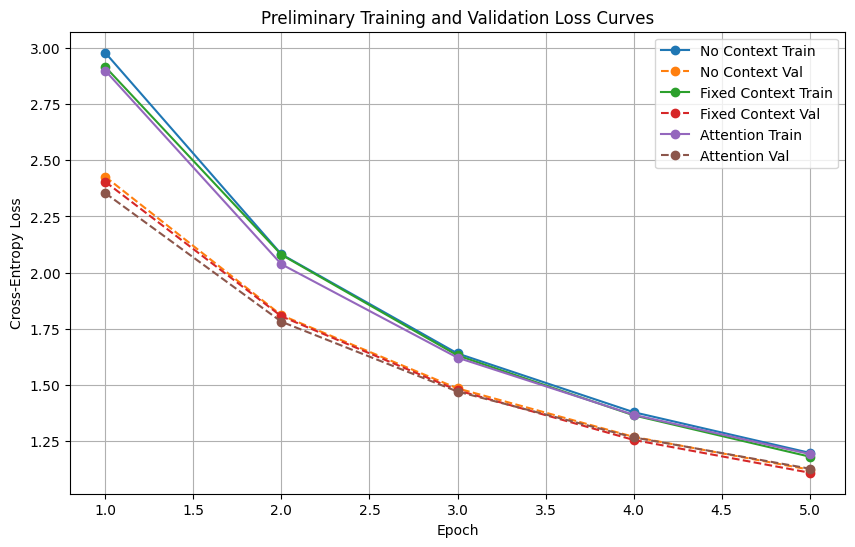

,Setup,Initial Train Loss,Final Train Loss,Initial Val Loss,Final Val Loss,Epochs
0,No Context,2.979501,1.197156,2.427303,1.122082,5
1,Fixed Context,2.916575,1.180106,2.404708,1.108653,5
2,Attention,2.899701,1.191810,2.354239,1.126593,5


In [15]:
PRELIM_EPOCHS = 5
PRELIM_LEARNING_RATE = 1e-4
PRELIM_EMBED_DIM = 64
PRELIM_HIDDEN_SIZE = 128
PRELIM_NUM_LAYERS = 1

print("Preliminary Training Configuration:")
print("Epochs:", PRELIM_EPOCHS)
print("Learning rate:", PRELIM_LEARNING_RATE)
print("Embedding dimension:", PRELIM_EMBED_DIM)
print("Hidden size:", PRELIM_HIDDEN_SIZE)
print("Number of layers:", PRELIM_NUM_LAYERS)
print("Batch size:", BATCH_SIZE)

def train_preliminary_setup(context_mode, setup_name):
    """
    Trains one model setup using the preliminary Section 4 configuration.
    This demonstrates that all three setups can be trained with
    cross-entropy loss, Adam, and gradient clipping.
    """

    print(f"\nPreliminary training: {setup_name}")
    print("-" * 60)

    set_all_seeds(SEED)

    model = build_seq2seq_model(
        embed_dim=PRELIM_EMBED_DIM,
        hidden_size=PRELIM_HIDDEN_SIZE,
        context_mode=context_mode,
        num_layers=PRELIM_NUM_LAYERS
    ).to(DEVICE)

    set_all_seeds(SEED)

    train_losses, val_losses = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=PRELIM_EPOCHS,
        learning_rate=PRELIM_LEARNING_RATE,
        device=DEVICE,
        max_grad_norm=1.0
    )

    return model, train_losses, val_losses

prelim_models = {}
prelim_histories = {}

prelim_model_none, prelim_train_none, prelim_val_none = train_preliminary_setup(
    context_mode="none",
    setup_name="Setup 1: No Context"
)

prelim_models["No Context"] = prelim_model_none
prelim_histories["No Context"] = {
    "train_losses": prelim_train_none,
    "val_losses": prelim_val_none
}

prelim_model_fixed, prelim_train_fixed, prelim_val_fixed = train_preliminary_setup(
    context_mode="fixed",
    setup_name="Setup 2: Fixed Context"
)

prelim_models["Fixed Context"] = prelim_model_fixed
prelim_histories["Fixed Context"] = {
    "train_losses": prelim_train_fixed,
    "val_losses": prelim_val_fixed
}

prelim_model_attn, prelim_train_attn, prelim_val_attn = train_preliminary_setup(
    context_mode="attn",
    setup_name="Setup 3: Attention"
)

prelim_models["Attention"] = prelim_model_attn
prelim_histories["Attention"] = {
    "train_losses": prelim_train_attn,
    "val_losses": prelim_val_attn
}

def plot_preliminary_loss_curves(prelim_histories, save_path=None):
    plt.figure(figsize=(10, 6))

    for setup_name, history in prelim_histories.items():
        train_losses = history["train_losses"]
        val_losses = history["val_losses"]
        epochs = range(1, len(train_losses) + 1)

        plt.plot(epochs, train_losses, marker="o", label=f"{setup_name} Train")
        plt.plot(epochs, val_losses, marker="o", linestyle="--", label=f"{setup_name} Val")

    plt.title("Preliminary Training and Validation Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

plot_preliminary_loss_curves(
    prelim_histories,
    save_path="results/preliminary_training_loss_curves.png"
)

preliminary_training_summary = []

for setup_name, history in prelim_histories.items():
    preliminary_training_summary.append({
        "Setup": setup_name,
        "Initial Train Loss": history["train_losses"][0],
        "Final Train Loss": history["train_losses"][-1],
        "Initial Val Loss": history["val_losses"][0],
        "Final Val Loss": history["val_losses"][-1],
        "Epochs": PRELIM_EPOCHS
    })

preliminary_training_summary_df = pd.DataFrame(preliminary_training_summary)

display(preliminary_training_summary_df)

preliminary_training_summary_df.to_csv(
    "results/preliminary_training_summary.csv",
    index=False
)

_________

### 5. Hyperparameter Tuning [3 marks]

In [16]:
# Tuning Setup
def clean_phoneme_ids(token_ids):
    """
    Converts a sequence of phoneme token IDs into a clean list of phoneme symbols.
    Removes <PAD> and <SOS>, and stops at <EOS>.
    """
    cleaned = []

    pad_idx = phoneme_to_idx["<PAD>"]
    sos_idx = phoneme_to_idx["<SOS>"]
    eos_idx = phoneme_to_idx["<EOS>"]

    for idx in token_ids:
        idx = int(idx)

        if idx == pad_idx or idx == sos_idx:
            continue

        if idx == eos_idx:
            break

        cleaned.append(idx_to_phoneme[idx])

    return cleaned

def evaluate_per(model, data_loader, device, max_len=30, max_batches=None):
    """
    Computes average phoneme error rate (PER) over a data loader.

    For each word:
        PER = edit distance(predicted phonemes, target phonemes) / length(target phonemes)

    Reported PER:
        average PER across all examples
    """

    model.eval()

    per_values = []

    with torch.no_grad():
        for batch_idx, (src_batch, target_batch) in enumerate(data_loader, start=1):
            src_batch = src_batch.to(device)
            target_batch = target_batch.to(device)

            predicted_ids = model.greedy_decode(src_batch, max_len=max_len)

            for pred_seq, target_seq in zip(predicted_ids, target_batch):
                pred_phonemes = clean_phoneme_ids(pred_seq.cpu().tolist())
                target_phonemes = clean_phoneme_ids(target_seq.cpu().tolist())

                if len(target_phonemes) == 0:
                    continue

                edit_dist = editdistance.eval(pred_phonemes, target_phonemes)
                per = edit_dist / len(target_phonemes)

                per_values.append(per)

            if max_batches is not None and batch_idx >= max_batches:
                break

    if len(per_values) == 0:
        return 0.0

    return sum(per_values) / len(per_values)

def tune_configuration(embed_dim, hidden_size, learning_rate, train_loader, val_loader, num_epochs, device, max_grad_norm=1.0, max_val_batches_for_per=None):
    """
    Trains a Setup 1 no-context model for a small number of epochs,
    then evaluates validation loss and validation PER.
    """

    set_all_seeds(SEED)

    model = build_seq2seq_model(
        embed_dim=embed_dim,
        hidden_size=hidden_size,
        context_mode="none",
        num_layers=1
    ).to(device)

    train_losses, val_losses = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        learning_rate=learning_rate,
        device=device,
        max_grad_norm=max_grad_norm
    )

    val_per = evaluate_per(
        model=model,
        data_loader=val_loader,
        device=device,
        max_len=30,
        max_batches=max_val_batches_for_per
    )

    result = {
        "learning_rate": learning_rate,
        "embed_dim": embed_dim,
        "hidden_size": hidden_size,
        "final_train_loss": train_losses[-1],
        "final_val_loss": val_losses[-1],
        "val_PER": val_per
    }

    return result, model, train_losses, val_losses

TUNE_EPOCHS = 5

# For speed during tuning:
MAX_VAL_BATCHES_FOR_PER = 30

# Tuning Experiments

# Learning Rate Tuning
learning_rates = [1e-3, 1e-4, 1e-5]

lr_results = []

for lr in learning_rates:
    print(f"\nTuning learning rate: {lr}")

    result, _, _, _ = tune_configuration(
        embed_dim=32,
        hidden_size=64,
        learning_rate=lr,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=TUNE_EPOCHS,
        device=DEVICE,
        max_grad_norm=1.0,
        max_val_batches_for_per=MAX_VAL_BATCHES_FOR_PER
    )

    lr_results.append(result)

lr_results_df = pd.DataFrame(lr_results)
lr_results_df
print("")
print(lr_results_df[["learning_rate", "final_val_loss", "val_PER"]])    

best_lr = lr_results_df.sort_values("val_PER").iloc[0]["learning_rate"]
print("Best learning rate:", best_lr)
print("")
print("-" * 50)
print("-" * 50)
print("")

# Tune Embedding Dimension
embedding_dims = [32, 64, 128]

embed_results = []

for embed_dim in embedding_dims:
    print(f"\nTuning embedding dimension: {embed_dim}")

    result, _, _, _ = tune_configuration(
        embed_dim=embed_dim,
        hidden_size=64,
        learning_rate=best_lr,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=TUNE_EPOCHS,
        device=DEVICE,
        max_grad_norm=1.0,
        max_val_batches_for_per=MAX_VAL_BATCHES_FOR_PER
    )

    embed_results.append(result)

embed_results_df = pd.DataFrame(embed_results)
embed_results_df
print("")
print(embed_results_df[["embed_dim", "final_val_loss", "val_PER"]])

best_embed_dim = int(embed_results_df.sort_values("val_PER").iloc[0]["embed_dim"])
print("Best embedding dimension:", best_embed_dim)
print("")
print("-" * 50)
print("-" * 50)
print("")

# Tune Hidden Size
hidden_sizes = [64, 128, 256]

hidden_results = []

for hidden_size in hidden_sizes:
    print(f"\nTuning hidden size: {hidden_size}")

    result, _, _, _ = tune_configuration(
        embed_dim=best_embed_dim,
        hidden_size=hidden_size,
        learning_rate=best_lr,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=TUNE_EPOCHS,
        device=DEVICE,
        max_grad_norm=1.0,
        max_val_batches_for_per=MAX_VAL_BATCHES_FOR_PER
    )

    hidden_results.append(result)

hidden_results_df = pd.DataFrame(hidden_results)
hidden_results_df
print("")
print(hidden_results_df.sort_values("val_PER")[["hidden_size", "val_PER"]])

best_hidden_size = int(hidden_results_df.sort_values("val_PER").iloc[0]["hidden_size"])
print("Best hidden size:", best_hidden_size)
print("")
print("-" * 50)
print("-" * 50)
print("")

tuning_results_df = pd.concat(
    [
        lr_results_df.assign(tuning_stage="learning_rate"),
        embed_results_df.assign(tuning_stage="embedding_dim"),
        hidden_results_df.assign(tuning_stage="hidden_size")
    ],
    ignore_index=True
)

tuning_results_df
tuning_results_df.to_csv("results/hyperparameter_tuning_results.csv", index=False)

print("All Tuning Results:")
print(tuning_results_df.sort_values("val_PER")[["tuning_stage", "learning_rate", "embed_dim", "hidden_size", "val_PER"]])
print("")
print("-" * 50)
print("")

# Selected Hyperparameters
selected_config = {
    "learning_rate": best_lr,
    "embed_dim": best_embed_dim,
    "hidden_size": best_hidden_size,
    "num_layers": 1
}

selected_config

print("Selected Hyperparameters:")
print("Learning rate:", selected_config["learning_rate"])
print("Embedding dimension:", selected_config["embed_dim"])
print("Hidden size:", selected_config["hidden_size"])
print("Number of layers:", selected_config["num_layers"])


Tuning learning rate: 0.001
    Batch 100/1445 | Avg Loss: 3.5575
    Batch 200/1445 | Avg Loss: 3.2968
    Batch 300/1445 | Avg Loss: 3.1394
    Batch 400/1445 | Avg Loss: 3.0221
    Batch 500/1445 | Avg Loss: 2.9162
    Batch 600/1445 | Avg Loss: 2.8190
    Batch 700/1445 | Avg Loss: 2.7314
    Batch 800/1445 | Avg Loss: 2.6500
    Batch 900/1445 | Avg Loss: 2.5728
    Batch 1000/1445 | Avg Loss: 2.4994
    Batch 1100/1445 | Avg Loss: 2.4298
    Batch 1200/1445 | Avg Loss: 2.3642
    Batch 1300/1445 | Avg Loss: 2.3026
    Batch 1400/1445 | Avg Loss: 2.2451
Epoch 01/5 | Train Loss: 2.2207 | Val Loss: 1.4240 | Epoch Time: 55.24s

--------------------------------------------------

    Batch 100/1445 | Avg Loss: 1.4046
    Batch 200/1445 | Avg Loss: 1.3849
    Batch 300/1445 | Avg Loss: 1.3617
    Batch 400/1445 | Avg Loss: 1.3398
    Batch 500/1445 | Avg Loss: 1.3189
    Batch 600/1445 | Avg Loss: 1.2998
    Batch 700/1445 | Avg Loss: 1.2838
    Batch 800/1445 | Avg Loss: 1.2642
    B

A learning rate of 0.001 was selected because it produced the lowest estimated validation PER of 0.2875 after 5 tuning epochs. The smaller learning rates, 0.0001 and 0.00001, converged much more slowly within the same training budget and achieved substantially higher validation PER values. An embedding dimension of 128 was selected because increasing the embedding size from 32 to 64 to 128 consistently improved validation PER, suggesting that richer character embeddings helped the model learn better grapheme representations. A hidden size of 256 was selected because it achieved the lowest estimated validation PER of 0.1376, outperforming hidden sizes of 64 and 128. These hyperparameters were selected using a greedy tuning strategy, where the best value from each stage was fixed before tuning the next hyperparameter.

_______

### 6. Architecture Comparison [3 marks]

#### Final Model Training

In [17]:
# Final hyperparameters selected from Section 5

FINAL_EPOCHS = 10
FINAL_LEARNING_RATE = selected_config["learning_rate"]
FINAL_EMBED_DIM = selected_config["embed_dim"]
FINAL_HIDDEN_SIZE = selected_config["hidden_size"]
FINAL_NUM_LAYERS = selected_config["num_layers"]

print("Final Training Configuration:")
print("Epochs:", FINAL_EPOCHS)
print("Learning rate:", FINAL_LEARNING_RATE)
print("Embedding dimension:", FINAL_EMBED_DIM)
print("Hidden size:", FINAL_HIDDEN_SIZE)
print("Number of layers:", FINAL_NUM_LAYERS)
print("Batch size:", BATCH_SIZE)
print("-" * 50)
print("-" * 50)
print("")

def train_final_setup(context_mode, setup_name):
    """
    Builds and trains one final Seq2Seq model setup.

    Parameters:
        context_mode: one of {"none", "fixed", "attn"}
        setup_name: display name for printing/saving

    Returns:
        model, train_losses, val_losses
    """

    print(f"Training {setup_name} model...")
    print("-" * 60)

    # Reset seed before model creation for reproducibility
    set_all_seeds(SEED)

    model = build_seq2seq_model(
        embed_dim=FINAL_EMBED_DIM,
        hidden_size=FINAL_HIDDEN_SIZE,
        context_mode=context_mode,
        num_layers=FINAL_NUM_LAYERS
    ).to(DEVICE)

    # Reset seed again before training so shuffling is as comparable as possible
    set_all_seeds(SEED)

    train_losses, val_losses = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=FINAL_EPOCHS,
        learning_rate=FINAL_LEARNING_RATE,
        device=DEVICE,
        max_grad_norm=1.0
    )

    # Save loss history
    history_df = pd.DataFrame({
        "epoch": list(range(1, FINAL_EPOCHS + 1)),
        "train_loss": train_losses,
        "val_loss": val_losses
    })

    history_df.to_csv(f"results/{context_mode}_loss_history.csv", index=False)

    # Save model weights
    torch.save(model.state_dict(), f"results/{context_mode}_model.pt")

    return model, train_losses, val_losses

# Train all three final setups under identical conditions

final_models = {}
final_histories = {}

# Setup 1: No context / bottleneck baseline
model_none, train_losses_none, val_losses_none = train_final_setup(
    context_mode="none",
    setup_name="Setup 1: No Context"
)

final_models["No Context"] = model_none
final_histories["No Context"] = {
    "train_losses": train_losses_none,
    "val_losses": val_losses_none
}

# Setup 2: Fixed context vector
model_fixed, train_losses_fixed, val_losses_fixed = train_final_setup(
    context_mode="fixed",
    setup_name="Setup 2: Fixed Context"
)

final_models["Fixed Context"] = model_fixed
final_histories["Fixed Context"] = {
    "train_losses": train_losses_fixed,
    "val_losses": val_losses_fixed
}

# Setup 3: Attention
model_attn, train_losses_attn, val_losses_attn = train_final_setup(
    context_mode="attn",
    setup_name="Setup 3: Attention"
)

final_models["Attention"] = model_attn
final_histories["Attention"] = {
    "train_losses": train_losses_attn,
    "val_losses": val_losses_attn
}

Final Training Configuration:
Epochs: 10
Learning rate: 0.001
Embedding dimension: 128
Hidden size: 256
Number of layers: 1
Batch size: 64
--------------------------------------------------
--------------------------------------------------

Training Setup 1: No Context model...
------------------------------------------------------------
    Batch 100/1445 | Avg Loss: 3.1039
    Batch 200/1445 | Avg Loss: 2.8021
    Batch 300/1445 | Avg Loss: 2.4951
    Batch 400/1445 | Avg Loss: 2.2137
    Batch 500/1445 | Avg Loss: 1.9920
    Batch 600/1445 | Avg Loss: 1.8187
    Batch 700/1445 | Avg Loss: 1.6812
    Batch 800/1445 | Avg Loss: 1.5693
    Batch 900/1445 | Avg Loss: 1.4767
    Batch 1000/1445 | Avg Loss: 1.3964
    Batch 1100/1445 | Avg Loss: 1.3291
    Batch 1200/1445 | Avg Loss: 1.2705
    Batch 1300/1445 | Avg Loss: 1.2183
    Batch 1400/1445 | Avg Loss: 1.1718
Epoch 01/10 | Train Loss: 1.1531 | Val Loss: 0.5342 | Epoch Time: 125.57s

-----------------------------------------------

#### Training and Validation Loss Curves

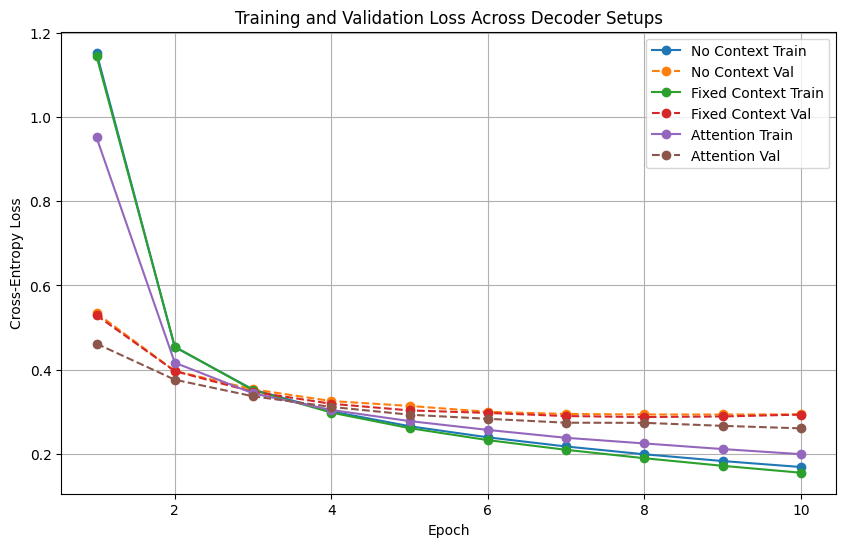

In [18]:
def plot_architecture_loss_curves(final_histories, save_path=None):
    """
    Plots training and validation loss curves for all final setups on shared axes.
    """

    plt.figure(figsize=(10, 6))

    for setup_name, history in final_histories.items():
        train_losses = history["train_losses"]
        val_losses = history["val_losses"]

        epochs = range(1, len(train_losses) + 1)

        plt.plot(
            epochs,
            train_losses,
            marker="o",
            label=f"{setup_name} Train"
        )

        plt.plot(
            epochs,
            val_losses,
            marker="o",
            linestyle="--",
            label=f"{setup_name} Val"
        )

    plt.title("Training and Validation Loss Across Decoder Setups")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

plot_architecture_loss_curves(
    final_histories,
    save_path="results/architecture_loss_curves.png"
)

#### Training Summary Report

In [19]:
convergence_summary = []

for setup_name, history in final_histories.items():
    val_losses = history["val_losses"]

    convergence_summary.append({
        "Setup": setup_name,
        "Initial Val Loss": val_losses[0],
        "Final Val Loss": val_losses[-1],
        "Best Val Loss": min(val_losses),
        "Best Val Epoch": int(np.argmin(val_losses) + 1)
    })

convergence_summary_df = pd.DataFrame(convergence_summary)

print("")
print("Convergence Summary:")
display(convergence_summary_df.style.format({
    "Initial Val Loss": "{:.4f}",
    "Final Val Loss": "{:.4f}",
    "Best Val Loss": "{:.4f}"
}))

convergence_summary_df.to_csv(
    "results/convergence_summary.csv",
    index=False
)


Convergence Summary:


,Setup,Initial Val Loss,Final Val Loss,Best Val Loss,Best Val Epoch
0,No Context,0.5342,0.2935,0.2932,9
1,Fixed Context,0.5291,0.2930,0.2871,8
2,Attention,0.4615,0.2603,0.2603,10


#### Error Analysis Example

In [20]:
def find_error_analysis_examples(model_a, model_b, data_loader, words, device, max_len=30, max_examples=3):
    """
    Finds examples where model_a fails but model_b succeeds.
    Intended use: Setup 1 fails but Setup 3 succeeds.
    """
    model_a.eval()
    model_b.eval()

    examples = []
    example_index = 0

    with torch.no_grad():
        for src_batch, target_batch in data_loader:
            src_batch = src_batch.to(device)
            target_batch = target_batch.to(device)

            preds_a = model_a.greedy_decode(src_batch, max_len=max_len)
            preds_b = model_b.greedy_decode(src_batch, max_len=max_len)

            batch_size = src_batch.size(0)

            for i in range(batch_size):
                word = words[example_index]

                target_phonemes = clean_phoneme_ids(target_batch[i].cpu().tolist())
                pred_a = clean_phoneme_ids(preds_a[i].cpu().tolist())
                pred_b = clean_phoneme_ids(preds_b[i].cpu().tolist())

                a_correct = pred_a == target_phonemes
                b_correct = pred_b == target_phonemes

                if (not a_correct) and b_correct:
                    examples.append({
                        "Word": word,
                        "Reference": " ".join(target_phonemes),
                        "Setup 1 Prediction": " ".join(pred_a),
                        "Setup 3 Prediction": " ".join(pred_b),
                        "Word Length": len(word)
                    })

                example_index += 1

                if len(examples) >= max_examples:
                    return pd.DataFrame(examples)

    return pd.DataFrame(examples)

error_examples_df = find_error_analysis_examples(
    model_a=model_none,
    model_b=model_attn,
    data_loader=test_loader,
    words=test_words,
    device=DEVICE,
    max_len=30,
    max_examples=3
)

display(error_examples_df)

error_examples_df.to_csv(
    "results/error_analysis_examples.csv",
    index=False
)

,Word,Reference,Setup 1 Prediction,Setup 3 Prediction,Word Length
0,vulgarization,V AH2 L G ER0 IH0 Z EY1 SH AH0 N,V AH2 L G ER0 AH0 Z EY1 SH AH0 N,V AH2 L G ER0 IH0 Z EY1 SH AH0 N,13
1,dickensheets,D IH1 K AH0 N SH IY2 T S,D IH1 K AH0 N SH EH2 T S,D IH1 K AH0 N SH IY2 T S,12
2,lucca,L UW1 K AH0,L UW1 K AH0 K,L UW1 K AH0,5


These examples show cases where the bottleneck model failed but the attention model produced the full correct phoneme sequence. This suggests that dynamic access to encoder hidden states can help the decoder recover relevant character-level information during generation, especially for longer or less regular words.

___________________

### 7. Evaluation [2 marks]

In [21]:
# Word Accuracy Function
def evaluate_word_accuracy(model, data_loader, device, max_len=30):
    """
    Computes word accuracy over a data loader.

    Word accuracy = fraction of examples where the entire predicted phoneme
    sequence exactly matches the target phoneme sequence.
    """

    model.eval()

    num_correct = 0
    num_examples = 0

    with torch.no_grad():
        for src_batch, target_batch in data_loader:
            src_batch = src_batch.to(device)
            target_batch = target_batch.to(device)

            predicted_ids = model.greedy_decode(src_batch, max_len=max_len)

            for pred_seq, target_seq in zip(predicted_ids, target_batch):
                pred_phonemes = clean_phoneme_ids(pred_seq.cpu().tolist())
                target_phonemes = clean_phoneme_ids(target_seq.cpu().tolist())

                if pred_phonemes == target_phonemes:
                    num_correct += 1

                num_examples += 1

    return num_correct / num_examples

In [22]:
# Final Evaluation Function
def evaluate_model(model, data_loader, criterion, device, max_len=30):
    """
    Evaluates a model using:
    - cross-entropy loss
    - phoneme error rate (PER)
    - word accuracy

    Returns:
        test_loss, test_per, word_accuracy
    """

    test_loss = evaluate_loss(
        model=model,
        data_loader=data_loader,
        criterion=criterion,
        device=device
    )

    test_per = evaluate_per(
        model=model,
        data_loader=data_loader,
        device=device,
        max_len=max_len,
        max_batches=None  # use full test set
    )

    word_accuracy = evaluate_word_accuracy(
        model=model,
        data_loader=data_loader,
        device=device,
        max_len=max_len
    )

    return test_loss, test_per, word_accuracy

# Final evaluation on the test set

criterion = nn.CrossEntropyLoss(ignore_index=phoneme_to_idx["<PAD>"])

evaluation_results = []

models_to_evaluate = {
    "Setup 1: No Context": model_none,
    "Setup 2: Fixed Context": model_fixed,
    "Setup 3: Attention": model_attn
}

for setup_name, model in models_to_evaluate.items():
    print(f"\nEvaluating {setup_name}...")

    test_loss, test_per, word_acc = evaluate_model(
        model=model,
        data_loader=test_loader,
        criterion=criterion,
        device=DEVICE,
        max_len=30
    )

    evaluation_results.append({
        "Setup": setup_name,
        "Test Loss": test_loss,
        "Test PER": test_per,
        "Word Accuracy": word_acc
    })

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test PER: {test_per:.4f}")
    print(f"Word Accuracy: {word_acc:.4f}")

evaluation_results_df = pd.DataFrame(evaluation_results)

evaluation_results_df

# Add percentage column
evaluation_results_df["Word Accuracy (%)"] = evaluation_results_df["Word Accuracy"] * 100

print("")
print("Final Test Evaluation Results:")
display(evaluation_results_df.style.format({
    "Test Loss": "{:.4f}",
    "Test PER": "{:.4f}",
    "Word Accuracy": "{:.4f}",
    "Word Accuracy (%)": "{:.2f}%"
}))

evaluation_results_df.to_csv(
    "results/final_evaluation_results.csv",
    index=False
)


Evaluating Setup 1: No Context...
Test Loss: 0.3100
Test PER: 0.1302
Word Accuracy: 0.5660

Evaluating Setup 2: Fixed Context...
Test Loss: 0.3075
Test PER: 0.1290
Word Accuracy: 0.5653

Evaluating Setup 3: Attention...
Test Loss: 0.2742
Test PER: 0.1237
Word Accuracy: 0.5685

Final Test Evaluation Results:


,Setup,Test Loss,Test PER,Word Accuracy,Word Accuracy (%)
0,Setup 1: No Context,0.3100,0.1302,0.5660,56.60%
1,Setup 2: Fixed Context,0.3075,0.1290,0.5653,56.53%
2,Setup 3: Attention,0.2742,0.1237,0.5685,56.85%


#### Architecture Comparison Summary for Report Discussion

In [23]:
# Extract rows for easier comparison
no_context = evaluation_results_df[
    evaluation_results_df["Setup"] == "Setup 1: No Context"
].iloc[0]

fixed_context = evaluation_results_df[
    evaluation_results_df["Setup"] == "Setup 2: Fixed Context"
].iloc[0]

attention = evaluation_results_df[
    evaluation_results_df["Setup"] == "Setup 3: Attention"
].iloc[0]

# Compute improvements
comparison_summary = {
    "Fixed Context vs No Context Test Loss Improvement":
        no_context["Test Loss"] - fixed_context["Test Loss"],

    "Fixed Context vs No Context PER Improvement":
        no_context["Test PER"] - fixed_context["Test PER"],

    "Fixed Context vs No Context Word Accuracy Change":
        fixed_context["Word Accuracy"] - no_context["Word Accuracy"],

    "Attention vs No Context Test Loss Improvement":
        no_context["Test Loss"] - attention["Test Loss"],

    "Attention vs No Context PER Improvement":
        no_context["Test PER"] - attention["Test PER"],

    "Attention vs No Context Word Accuracy Change":
        attention["Word Accuracy"] - no_context["Word Accuracy"],

    "Attention vs Fixed Context Test Loss Improvement":
        fixed_context["Test Loss"] - attention["Test Loss"],

    "Attention vs Fixed Context PER Improvement":
        fixed_context["Test PER"] - attention["Test PER"],

    "Attention vs Fixed Context Word Accuracy Change":
        attention["Word Accuracy"] - fixed_context["Word Accuracy"],
}

comparison_summary_df = pd.DataFrame(
    comparison_summary.items(),
    columns=["Comparison", "Difference"]
)

print("")
print("Architecture Comparison Summary:")
display(comparison_summary_df.style.format({
    "Difference": "{:.4f}"
}))

comparison_summary_df.to_csv(
    "results/architecture_comparison_summary.csv",
    index=False
)


Architecture Comparison Summary:


,Comparison,Difference
0,Fixed Context vs No Context Test Loss Improvement,0.0025
1,Fixed Context vs No Context PER Improvement,0.0012
2,Fixed Context vs No Context Word Accuracy Change,-0.0008
3,Attention vs No Context Test Loss Improvement,0.0358
4,Attention vs No Context PER Improvement,0.0065
5,Attention vs No Context Word Accuracy Change,0.0025
6,Attention vs Fixed Context Test Loss Improvement,0.0333
7,Attention vs Fixed Context PER Improvement,0.0053
8,Attention vs Fixed Context Word Accuracy Change,0.0033


____________________

### 8. Bottleneck OR Attention Analysis[2 marks]

#### a. Length Analysis

In [24]:
def get_length_bucket(word):
    """
    Assigns a word to a length bucket based on number of characters.
    """
    length = len(word)

    if length <= 4:
        return "1-4"
    elif length <= 7:
        return "5-7"
    elif length <= 10:
        return "8-10"
    else:
        return "11+"
    
def evaluate_word_accuracy_by_length(model, data_loader, words, device, max_len=30):
    """
    Computes word accuracy for each word-length bucket.

    Parameters:
        model: trained Seq2Seq model
        data_loader: test_loader
        words: original list of test words, in the same order as test_dataset
        device: CPU/GPU
        max_len: maximum decoding length

    Returns:
        bucket_accuracies: dictionary mapping bucket -> word accuracy
    """

    model.eval()

    bucket_correct = {
        "1-4": 0,
        "5-7": 0,
        "8-10": 0,
        "11+": 0
    }

    bucket_total = {
        "1-4": 0,
        "5-7": 0,
        "8-10": 0,
        "11+": 0
    }

    example_index = 0

    with torch.no_grad():
        for src_batch, target_batch in data_loader:
            src_batch = src_batch.to(device)
            target_batch = target_batch.to(device)

            predicted_ids = model.greedy_decode(src_batch, max_len=max_len)

            batch_size = src_batch.size(0)

            for i in range(batch_size):
                word = words[example_index]
                bucket = get_length_bucket(word)

                pred_phonemes = clean_phoneme_ids(predicted_ids[i].cpu().tolist())
                target_phonemes = clean_phoneme_ids(target_batch[i].cpu().tolist())

                if pred_phonemes == target_phonemes:
                    bucket_correct[bucket] += 1

                bucket_total[bucket] += 1
                example_index += 1

    bucket_accuracies = {}

    for bucket in bucket_total:
        if bucket_total[bucket] == 0:
            bucket_accuracies[bucket] = 0.0
        else:
            bucket_accuracies[bucket] = bucket_correct[bucket] / bucket_total[bucket]

    return bucket_accuracies

In [25]:
models_for_length_analysis = {
    "No Context": model_none,
    "Fixed Context": model_fixed,
    "Attention": model_attn
}

length_analysis_results = []

for setup_name, model in models_for_length_analysis.items():
    print(f"Computing length-bucket accuracy for {setup_name}...")

    bucket_accuracies = evaluate_word_accuracy_by_length(
        model=model,
        data_loader=test_loader,
        words=test_words,
        device=DEVICE,
        max_len=30
    )

    for bucket, accuracy in bucket_accuracies.items():
        length_analysis_results.append({
            "Setup": setup_name,
            "Length Bucket": bucket,
            "Word Accuracy": accuracy
        })

length_analysis_df = pd.DataFrame(length_analysis_results)

length_analysis_df

Computing length-bucket accuracy for No Context...
Computing length-bucket accuracy for Fixed Context...
Computing length-bucket accuracy for Attention...


,Setup,Length Bucket,Word Accuracy
0,No Context,1-4,0.770087
1,No Context,5-7,0.629055
2,No Context,8-10,0.488651
3,No Context,11+,0.345331
4,Fixed Context,1-4,0.760198
5,Fixed Context,5-7,0.635438
6,Fixed Context,8-10,0.482530
7,Fixed Context,11+,0.331712
8,Attention,1-4,0.749073
9,Attention,5-7,0.623016


##### Pivot Table

In [26]:
length_analysis_pivot = length_analysis_df.pivot(
    index="Length Bucket",
    columns="Setup",
    values="Word Accuracy"
)

# Keep buckets in logical order
bucket_order = ["1-4", "5-7", "8-10", "11+"]
length_analysis_pivot = length_analysis_pivot.loc[bucket_order]

print("Word Accuracy by Length Bucket:")
display(length_analysis_pivot.style.format("{:.4f}").background_gradient(cmap="Blues"))

length_analysis_pivot
length_analysis_pivot.to_csv("results/length_analysis_word_accuracy.csv")

Word Accuracy by Length Bucket:


Setup,Attention,Fixed Context,No Context
Length Bucket,,,
1-4,0.7491,0.7602,0.7701
5-7,0.6230,0.6354,0.6291
8-10,0.4983,0.4825,0.4887
11+,0.3872,0.3317,0.3453


#### Grouped Bar Chart For Length Analsis

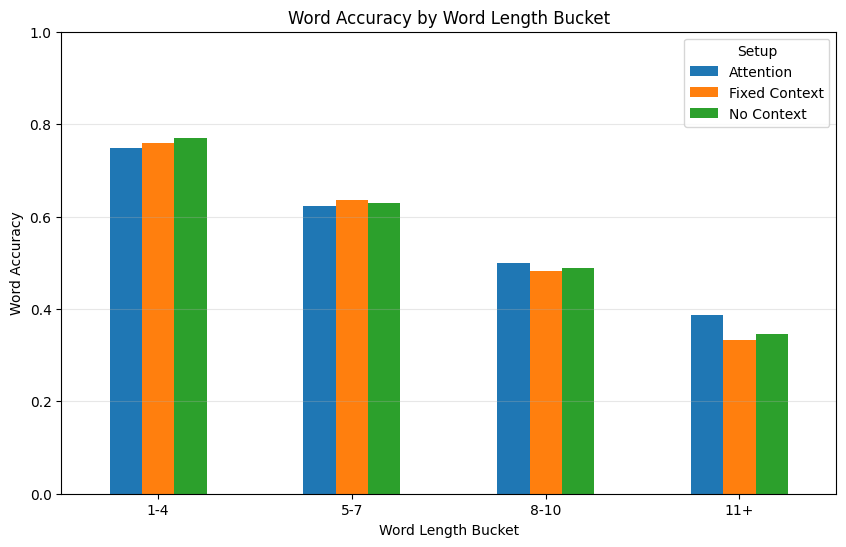

In [27]:
ax = length_analysis_pivot.plot(
    kind="bar",
    figsize=(10, 6),
    rot=0
)

plt.title("Word Accuracy by Word Length Bucket")
plt.xlabel("Word Length Bucket")
plt.ylabel("Word Accuracy")
plt.ylim(0, 1)
plt.legend(title="Setup")
plt.grid(axis="y", alpha=0.3)

plt.savefig("results/length_analysis_grouped_bar_chart.png", dpi=300, bbox_inches="tight")
plt.show()

### Additional attention visualisations for report
Although the main analysis uses word-length buckets, the final report also includes attention heatmaps to illustrate how the attention model distributes focus over input characters during decoding.

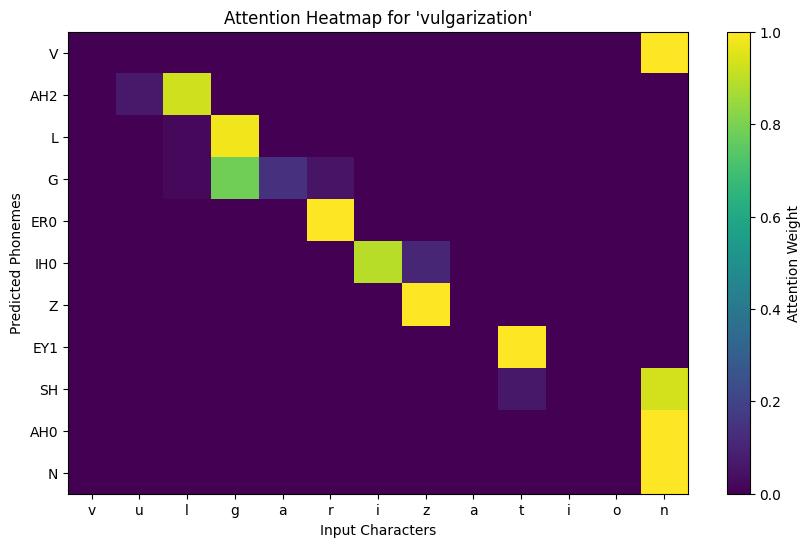

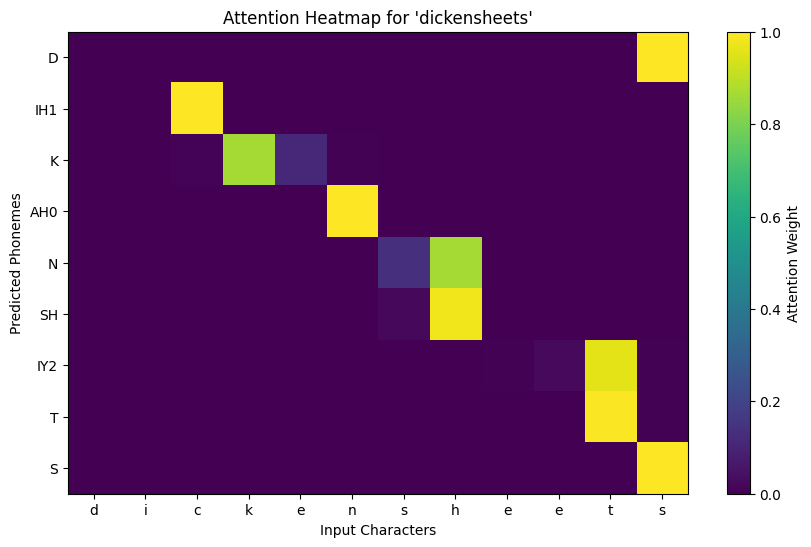

In [28]:
def get_single_prediction_with_attention(model, word, char_to_idx, idx_to_phoneme, device, max_len=30):
    """
    Runs greedy decoding on a single word and returns:
    - input characters
    - predicted phonemes
    - attention matrix
    """

    model.eval()

    char_unk_idx = char_to_idx["<UNK>"]

    src_ids = [
        char_to_idx.get(char, char_unk_idx)
        for char in word.lower()
    ]

    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_ids = model.greedy_decode(src_tensor, max_len=max_len)

    predicted_phonemes = clean_phoneme_ids(predicted_ids[0].cpu().tolist())

    attention_weights = model.decoder.attention_weights
    # shape: (batch, generated_len, src_len)

    if attention_weights is None:
        raise ValueError("No attention weights found. Make sure the model uses context_mode='attn'.")

    attention_matrix = attention_weights[0].cpu().numpy()

    # Match attention rows to number of predicted phonemes
    attention_matrix = attention_matrix[:len(predicted_phonemes), :len(word)]

    input_chars = list(word.lower())

    return input_chars, predicted_phonemes, attention_matrix


def plot_attention_heatmap(model, word, char_to_idx, idx_to_phoneme, device, save_path=None):
    input_chars, predicted_phonemes, attention_matrix = get_single_prediction_with_attention(
        model=model,
        word=word,
        char_to_idx=char_to_idx,
        idx_to_phoneme=idx_to_phoneme,
        device=device,
        max_len=30
    )

    plt.figure(figsize=(10, 6))
    plt.imshow(attention_matrix, aspect="auto")

    plt.xticks(
        ticks=np.arange(len(input_chars)),
        labels=input_chars
    )

    plt.yticks(
        ticks=np.arange(len(predicted_phonemes)),
        labels=predicted_phonemes
    )

    plt.xlabel("Input Characters")
    plt.ylabel("Predicted Phonemes")
    plt.title(f"Attention Heatmap for '{word}'")
    plt.colorbar(label="Attention Weight")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

attention_words = ["vulgarization", "dickensheets"]

for word in attention_words:
    plot_attention_heatmap(
        model=model_attn,
        word=word,
        char_to_idx=char_to_idx,
        idx_to_phoneme=idx_to_phoneme,
        device=DEVICE,
        save_path=f"results/attention_heatmap_{word}.png"
    )

### 9. Code Quality & Reproducibility [3 marks]

#### Reproducibility Check
All random seeds are fixed at the top of the notebook using the same SEED value for Python's random module, NumPy, and PyTorch. If CUDA is available, the CUDA random seeds are also fixed. The train, validation, and test splits are loaded from the provided CSV files and are not regenerated inside the notebook. The vocabulary is built only from the training data, ensuring that validation and test examples do not leak into preprocessing.

#### Notes for Running the Notebook
Required Python libraries are: numpy, pandas, matplotlib, torch, and editdistance. The notebook saves plots, model weights, and result tables to the results/ directory.

#### Conclusions / Save Results

The final trained models and result tables are saved in the results/ folder. The same selected hyperparameters are used for all three architecture variants, making the final comparison fair. Final evaluation is performed on the held-out test set using test loss, phoneme error rate, and word accuracy.

______________________